In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib
import os

# 1. Configuration
DATA_PATH = r'f:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\data\processed\img_biomarkers3.csv'
MODEL_DIR = r'F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models'
if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)

# 2. Ingestion
print(f"Loading dataset from {DATA_PATH}...")
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    # Fallback for report generation context if file missing locally
    print("File not found. Please ensure the path is correct.")
    # In a real run, this would raise Error.

# 3. Preprocessing
# Assume columns:
features = ['ear', 'mar', 'brow_score']
target = 'label'

# Handle Missing Data
df = df.dropna(subset=features + [target])

# Encode Target
if df[target].dtype == 'object':
    df[target] = df[target].apply(lambda x: 1 if 'pain' in str(x).lower() and 'no' not in str(x).lower() else 0)

X = df[features]
y = df[target]

# 4. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 5. Model Training (Random Forest)
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)

print("Training Random Forest Classifier...")
rf.fit(X_train, y_train)

# 6. Serialization
model_path = os.path.join(MODEL_DIR, 'img_rf_pain_classifier3.pkl')
joblib.dump(rf, model_path)
print(f"Model saved to: {model_path}")


Loading dataset from f:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\data\processed\img_biomarkers3.csv...
Training Random Forest Classifier...
Model saved to: F:\Research\Project\Final\infant-growth-monitoring-system\mlModels\CryTranslater\saved_models\img_rf_pain_classifier3.pkl


Class Distribution in Test Set:
y_test unique values: [0 1]
y_test value counts: [268 581]

y_pred unique values: [0 1]
y_pred value counts: [309 540]
MODEL PERFORMANCE METRICS
Accuracy:  0.7020 (70.20%)
Precision: 0.8037
Recall:    0.7470
F1-Score:  0.7743

Detailed Classification Report:
              precision    recall  f1-score   support

     No Pain       0.52      0.60      0.56       268
        Pain       0.80      0.75      0.77       581

    accuracy                           0.70       849
   macro avg       0.66      0.68      0.67       849
weighted avg       0.72      0.70      0.71       849


Confusion Matrix:
[[162 106]
 [147 434]]


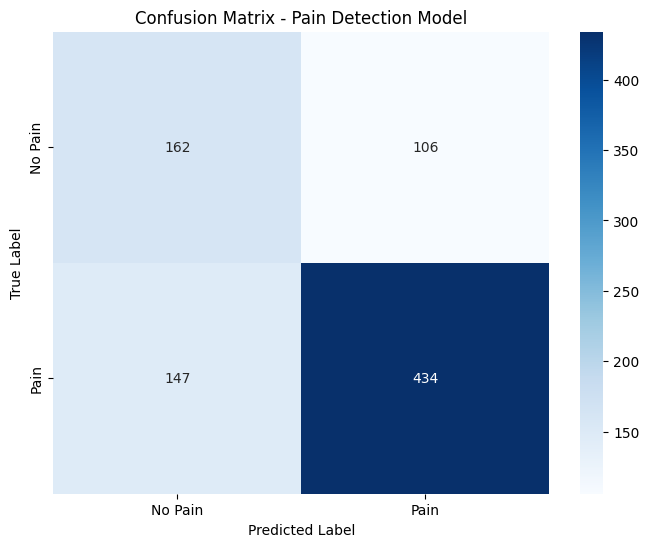

In [9]:
# 7. Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Make predictions
y_pred = rf.predict(X_test)

# Diagnostic: Check class distribution
print("Class Distribution in Test Set:")
print(f"y_test unique values: {np.unique(y_test)}")
print(f"y_test value counts: {np.bincount(y_test)}")
print(f"\ny_pred unique values: {np.unique(y_pred)}")
print(f"y_pred value counts: {np.bincount(y_pred)}")
print("="*50)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*50)

# Detailed classification report - specify labels explicitly
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['No Pain', 'Pain'], zero_division=0))

# Confusion Matrix - specify labels explicitly
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Pain', 'Pain'], 
            yticklabels=['No Pain', 'Pain'])
plt.title('Confusion Matrix - Pain Detection Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'))
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33796\3813452870.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[indices], y=np.array(features)[indices], palette='viridis')


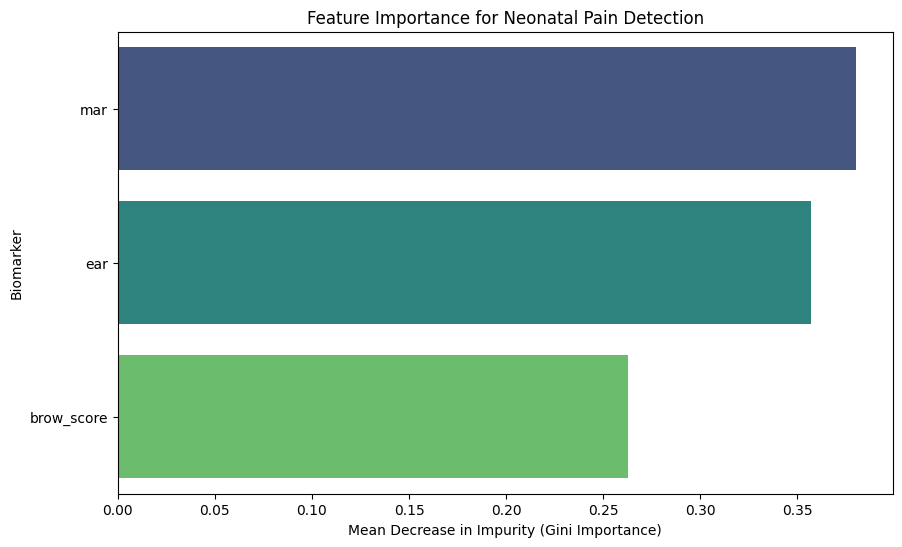

In [10]:
import seaborn as sns

feature_importances = rf.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[indices], y=np.array(features)[indices], palette='viridis')
plt.title('Feature Importance for Neonatal Pain Detection')
plt.xlabel('Mean Decrease in Impurity (Gini Importance)')
plt.ylabel('Biomarker')
plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'))
plt.show()